# <p style="text-align: center; color: red;"> Modelling and Control of Cement Emissions using ML</p> 

# <p style="text-align: left; color: yellow;"> Sheikh Junaid Fayaz -- M3RG Lab -- Indian Institute of Technology, Delhi</p> 
# <p style="text-align: left; color: yellow;"> Date : 06 March 2026</p> 

In [ ]:
import sys
sys.path.append('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks')
import functions  # First import
import importlib
importlib.reload(functions)  # Reload to reflect changes
from functions import *  # Now import updated functions

#add_custom_fonts(loc=".myfonts")
# import subprocess
# from shadow.plot import *
# from new_plot import * #This line is throwing an error #Solved by commenting out some of the keys of rcParams()

# Read data

In [2]:
filtered_palnt_d = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/filtered_plant_c_nox.pkl')
np.random.seed(1002)
random.seed(0)

X = filtered_palnt_d.iloc[:,1:]
y = filtered_palnt_d.iloc[:,[0]]

X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=100)

# All model training (CO)

### SVR works best

In [3]:
titles = ['Linear regression', 'Lasso', 'Ridge', 'Elastic net', 'Random forest', 'XGBoost', 'SVR', 'GPR', 'NN']

In [4]:
train_scores = []
val_scores = []
test_scores = []

# LR

LinearRegression()

Avg Training:  R^2 = 0.54, MAE = 148.28, MAPE = 37.51%
Avg Val:  R^2 = 0.51, MAE = 152.74, MAPE = 38.81%
Test 0.56 143.38 36.13


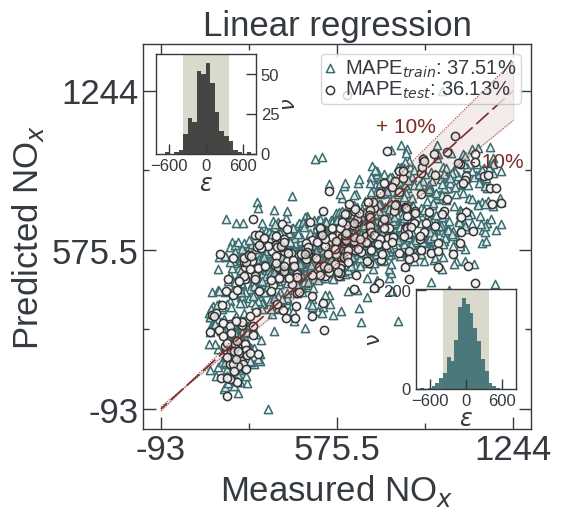

In [5]:
best_regressor = LinearRegression()
best_regressor.fit(X_train, y_train)

avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant3/{titles[0]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[0],'NO$_{x}$', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

# Lasso

GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB
Fitting 1 folds for each of 4 candidates, totalling 4 fits
[CV] END ........................................alpha=1e-05; total time=   0.0s
[CV] END .......................................alpha=0.0001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 0.0302 s
System CPU time  : 0.0278 s
Total CPU time   : 0.0579 s
Wall clock time  : 0.5559 s

---- CPU Utilization Stats ----
Avg CPU usage    : 0.00%
Max CPU usage    : 0.00%
Logical cores    : 64
Physical cores   : 32


{'alpha': 1e-05}

Avg Training:  R^2 = 0.54, MAE = 148.28, MAPE = 37.51%
Avg Val:  R^2 = 0.51, MAE = 152.73, MAPE = 38.81%
Test 0.56 143.33 36.12


X has feature names, but Lasso was fitted without feature names
X has feature names, but Lasso was fitted without feature names
X has feature names, but Lasso was fitted without feature names


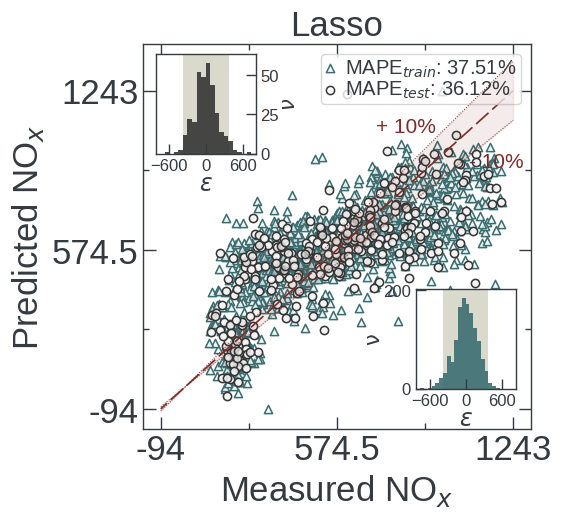

In [6]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = Lasso()
hyperparameter_grid= {'alpha': [0.00001, 0.0001,0.001, 0.1]} 
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
                                                       iterations = 4, verbose= 2)
end_profiling(save_path = None, note = None)
random_search.best_params_

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= None)
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant3/{titles[1]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[1],'NO$_{x}$', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)  
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

# Ridge

GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB
Fitting 1 folds for each of 4 candidates, totalling 4 fits
[CV] END ........................................alpha=1e-05; total time=   0.0s
[CV] END .......................................alpha=0.0001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s


{'alpha': 1e-05}

GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 0.0280 s
System CPU time  : 0.0240 s
Total CPU time   : 0.0520 s
Wall clock time  : 0.5538 s

---- CPU Utilization Stats ----
Avg CPU usage    : 0.00%
Max CPU usage    : 0.00%
Logical cores    : 64
Physical cores   : 32
Avg Training:  R^2 = 0.54, MAE = 148.47, MAPE = 37.56%
Avg Val:  R^2 = 0.51, MAE = 152.95, MAPE = 38.88%
Test 0.56 142.93 36.01


X has feature names, but Ridge was fitted without feature names
X has feature names, but Ridge was fitted without feature names
X has feature names, but Ridge was fitted without feature names


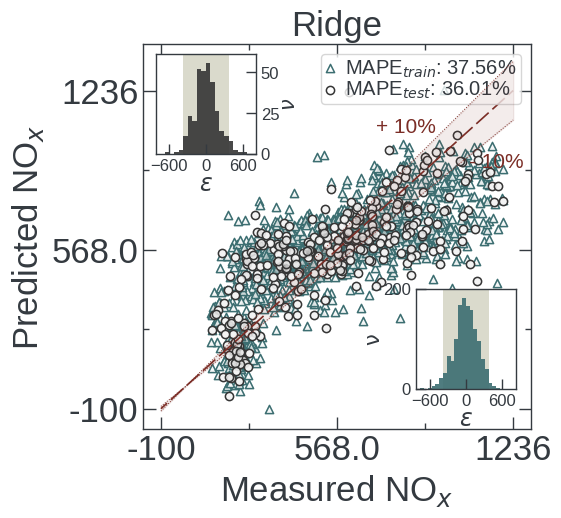

In [7]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = Ridge()
hyperparameter_grid= {'alpha': [0.00001, 0.0001,0.001, 0.1]} 
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
                                                       iterations = 4, verbose= 2)
random_search.best_params_
end_profiling(save_path = None, note = None)

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= None)
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant3/{titles[2]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[2],'NO$_{x}$', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

# Elastic net

GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB
Fitting 1 folds for each of 4 candidates, totalling 4 fits
[CV] END ........................................alpha=1e-05; total time=   0.0s
[CV] END .......................................alpha=0.0001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s


{'alpha': 1e-05}

GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 0.0532 s
System CPU time  : 0.0125 s
Total CPU time   : 0.0657 s
Wall clock time  : 0.5548 s

---- CPU Utilization Stats ----
Avg CPU usage    : 0.00%
Max CPU usage    : 0.00%
Logical cores    : 64
Physical cores   : 32
Avg Training:  R^2 = 0.52, MAE = 152.89, MAPE = 38.09%
Avg Val:  R^2 = 0.48, MAE = 158.17, MAPE = 39.73%
Test 0.54 146.75 36.39


X has feature names, but ElasticNet was fitted without feature names
X has feature names, but ElasticNet was fitted without feature names
X has feature names, but ElasticNet was fitted without feature names


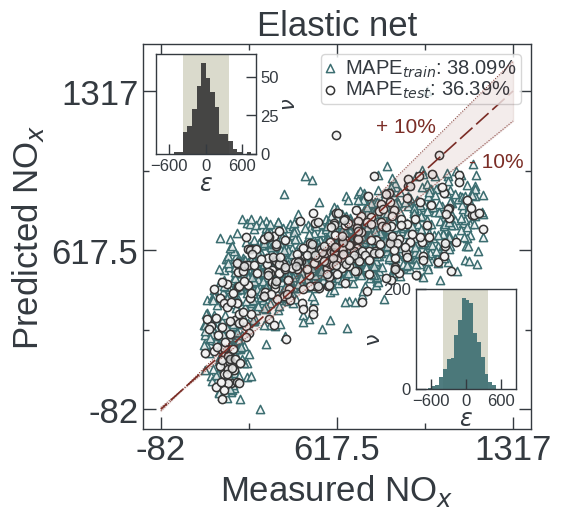

In [8]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = ElasticNet()
hyperparameter_grid= {'alpha': [0.00001, 0.0001,0.001, 0.1]} 
iterations = 4
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
                                                       iterations = 4, verbose= 2)
random_search.best_params_
end_profiling(save_path = None, note = None)

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= None)
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant3/{titles[3]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[3],'NO$_{x}$', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)  
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# Random forest

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


Avg Training:  R^2 = 0.99, MAE = 17.75, MAPE = 4.04%
Avg Val:  R^2 = 0.74, MAE = 103.08, MAPE = 23.43%
Test 0.78 92.62 19.99


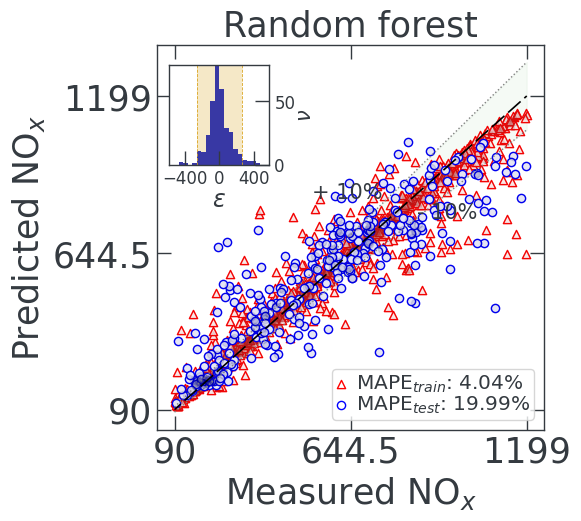

In [ ]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = RandomForestRegressor(random_state=42, n_jobs=-1)
hyperparameter_grid = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [12, 16, 20, 24, None],        # None = grow until pure
    "min_samples_split": [2, 4, 8, 16, 32],
    "min_samples_leaf": [1, 2, 4, 8, 12, 16],
    "max_features": [0.3, 0.4, 0.5, 0.6, "sqrt", "log2"],
    "ccp_alpha": [0.0, 0.0001, 0.0005, 0.001, 0.005],
    "bootstrap": [True, False]
}
iterations =100
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, np.ravel(y_train), # ravel for randomforest
                                                       iterations = iterations, verbose= 1)
random_search.best_params_
end_profiling(save_path = None, note = None)

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = 'plant3 nox random forest',log_file_path= '/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant3/random_forest.txt')
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant3/{titles[4]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[4],'NO$_{x}$', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

RandomForestRegressor(max_depth=24, max_features=0.4, min_samples_leaf=16,
                      min_samples_split=16, n_estimators=600, n_jobs=-1,
                      random_state=42)

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


Avg Training:  R^2 = 0.76, MAE = 101.72, MAPE = 24.43%
Avg Val:  R^2 = 0.66, MAE = 122.23, MAPE = 29.09%
Test 0.72 107.14 24.33


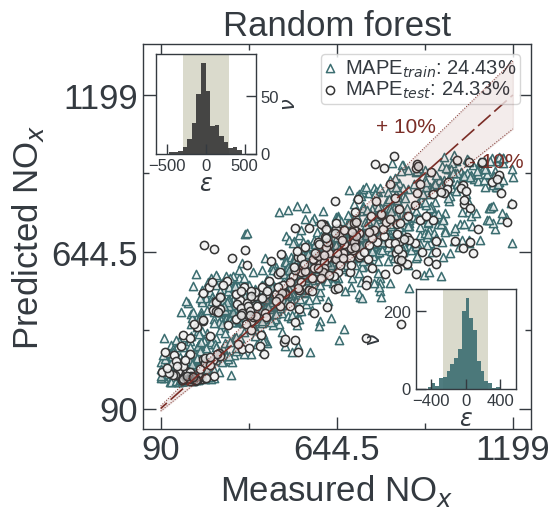

In [9]:
# best model overfit, this model is more genralizable model better
np.random.seed(1002)
random.seed(0)
best_regressor = RandomForestRegressor(random_state=42, n_jobs=-1, 
n_estimators= 600, min_samples_split= 16, min_samples_leaf= 16, max_features= 0.4, max_depth= 24, ccp_alpha= 0.0, bootstrap= True)
best_regressor.fit(X_train, np.ravel(y_train))
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant3/{titles[4]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[4],'NO$_{x}$', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# XGboost

In [ ]:
# np.random.seed(1002)
# random.seed(0)

# start_profiling() 
# regressor = XGBRegressor(random_state=42, tree_method='gpu_hist', n_jobs=-1)
# hyperparameter_grid = {
#     'learning_rate': [0.008, 0.01, 0.012, 0.015, 0.018],
#     'max_depth': [5, 6, 7],
#     'min_child_weight': [8, 9, 10, 11, 12],
#     'subsample': [0.6, 0.7, 0.8, 0.9],
#     'colsample_bytree': [0.5, 0.6, 0.7, 0.8],
#     'reg_alpha': [5, 6, 7, 8, 9, 10],
#     'reg_lambda': [5, 6, 7, 8, 9, 10],
#     'n_estimators': [400, 450, 500, 550, 600],
# }
# iterations =100
# best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
#                                                        iterations = iterations, verbose= 2)
# random_search.best_params_
# end_profiling(save_path='/home/m3rg2000/Junaid_temporary/saved_data/Time_cpu_stats/plant_compare/plant3_nox_hy_opt.txt',
#               note = 'plant3 nox hy pp optimization')

# # save Randomsearch results
# log_search_space(random_search.cv_results_, file_note = 'plant3 nox XGBoost',log_file_path= '/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant3/nox_xgb.txt')
# # k fold cross validation
# avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)  fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant3/{titles[0]}_parity.pdf'
# # parity plot
# test_results = parity_train_test(best_regressor, titles[5],'NO$_{x}$', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)  train_scores.append(tuple(avg_train_results)) val_scores.append(tuple(avg_val_results)) test_scores.append(tuple(test_results))

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.008, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=9, missing=nan, monotone_constraints=None,
             n_estimators=600, n_jobs=-1, num_parallel_tree=None,
             predictor=None, random_state=42, ...)

Avg Training:  R^2 = 0.87, MAE = 72.96, MAPE = 16.09%
Avg Val:  R^2 = 0.71, MAE = 109.64, MAPE = 24.51%
Test 0.77 94.2 19.95


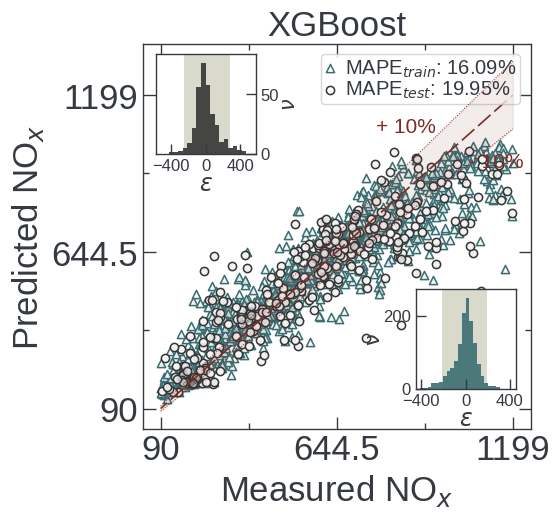

In [10]:
# best model overfit, iteration 76 is more genralizable model better
np.random.seed(1002)
random.seed(0)
best_regressor = XGBRegressor(random_state=42, tree_method='gpu_hist', n_jobs=-1,
subsample= 0.6, reg_lambda= 5, reg_alpha= 5, n_estimators= 600, min_child_weight= 9, max_depth= 5, learning_rate= 0.008, colsample_bytree= 0.7
)
best_regressor.fit(X_train, y_train)
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant3/{titles[5]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[5],'NO$_{x}$', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

# best model stats

In [12]:
start_profiling() 

np.random.seed(1002)
random.seed(0)
best_regressor = XGBRegressor(random_state=42, tree_method='gpu_hist', n_jobs=-1,
subsample= 0.6, reg_lambda= 5, reg_alpha= 5, n_estimators= 600, min_child_weight= 9, max_depth= 5, learning_rate= 0.008, colsample_bytree= 0.7
).fit(X_train,y_train)

end_profiling()
train_test_score(best_regressor, X_train, X_test, y_train, y_test)
save_model(best_regressor,
           model_path = f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant3/xgb_best.pkl')

model_size('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant3/xgb_best.pkl')

GPU 0: Utilization: 0%, Memory Used: 1038 MB / 12282 MB
GPU 0: Utilization: 10%, Memory Used: 1038 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 1038 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 10%, Memory Used: 1038 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 0.8662 s
System CPU time  : 0.0320 s
Total CPU time   : 0.8982 s
Wall clock time  : 1.0661 s

---- CPU Utilization Stats ----
Avg CPU usage    : 0.78%
Max CPU usage    : 1.56%
Logical cores    : 64
Physical cores   : 32
Training 0.86 74.65 16.48
Test 0.77 94.2 19.95
Model size: 1.09 MB


# SVR

GPU 0: Utilization: 0%, Memory Used: 467 MB / 12282 MB
Fitting 1 folds for each of 200 candidates, totalling 200 fits


{'model__regressor__tol': 0.0001,
 'model__regressor__shrinking': False,
 'model__regressor__kernel': 'rbf',
 'model__regressor__gamma': 'auto',
 'model__regressor__epsilon': 0.001,
 'model__regressor__degree': 2,
 'model__regressor__coef0': 0.1,
 'model__regressor__C': 1}

GPU 0: Utilization: 0%, Memory Used: 691 MB / 12282 MB
---- NOTE ----
RandomSearchCV for plant 4 SVR

---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 467 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 691 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 325.9958 s
System CPU time  : 0.1657 s
Total CPU time   : 326.1614 s
Wall clock time  : 326.1036 s

---- CPU Utilization Stats ----
Avg CPU usage    : 1.56%
Max CPU usage    : 1.62%
Logical cores    : 64
Physical cores   : 32
Avg Training:  R^2 = 0.8, MAE = 77.12, MAPE = 15.79%
Avg Val:  R^2 = 0.69, MAE = 110.87, MAPE = 24.4%
Test 0.74 104.08 23.17


X has feature names, but StandardScaler was fitted without feature names
X has feature names, but StandardScaler was fitted without feature names
X has feature names, but StandardScaler was fitted without feature names


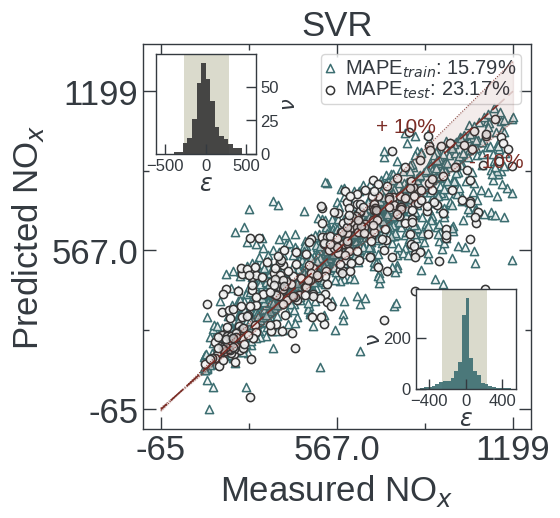

In [11]:
np.random.seed(1002)
random.seed(0)
start_profiling() 

pipeline = Pipeline([      
    ('scaler_X', StandardScaler()), 
    ('model', TransformedTargetRegressor(
        regressor= SVR(),
        transformer=StandardScaler()))
])
hyperparameter_grid = {
    "kernel":  ["rbf", "poly", "sigmoid"],
    "C":       [0.1, 1, 10, 50, 100, 200, 500],
    "epsilon": [0.001, 0.01, 0.05, 0.1, 0.2, 0.5],
    "gamma":   ["scale", "auto", 1e-4, 1e-3, 1e-2, 1e-1],
    "degree":  [2, 3, 4],          
    "coef0":   [0.0, 0.1, 0.5, 1.0],
    "tol":     [1e-4, 1e-3, 1e-2],
    "shrinking": [True, False]
}

iterations = 200
best_regressor,random_search = RandomSearchCV_pipeline(pipeline, flatten_grid(hyperparameter_grid), X_train, y_train, 
                                                       iterations = iterations, verbose= 1)
random_search.best_params_
end_profiling(save_path = None,
              note = 'RandomSearchCV for plant 4 SVR')

# save_model(best_regressor,
#            model_path =f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant3/svr_best.pkl') # =None if not want to save

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= "/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant3/svr.txt")
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)  
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant3/{titles[6]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[6],'NO$_{x}$', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

In [ ]:
# # Iteration 
# regressor = SVR(
    
# )
# pipeline = Pipeline([      
#     ('scaler_X', StandardScaler()), 
#     ('model', TransformedTargetRegressor(
#         regressor= regressor,
#         transformer=StandardScaler()))
# ])
# pipeline.fit(X_train, y_train)
# avg_train_results, avg_val_results = k_fold_scores(pipeline, X_train, y_train)  fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant3/{titles[]}_parity.pdf'
# test_results = parity_train_test(pipeline, titles[6],'NO$_{x}$', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)  train_scores.append(tuple(avg_train_results)) val_scores.append(tuple(avg_val_results)) test_scores.append(tuple(test_results))

# GPR

GPU 0: Utilization: 0%, Memory Used: 298 MB / 12282 MB
Fitting 1 folds for each of 200 candidates, totalling 200 fits


The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
The optimal value found for dimension 0 of parameter k2__noise_level is clos

{'model__regressor__normalize_y': True,
 'model__regressor__kernel': 1**2 * RationalQuadratic(alpha=1, length_scale=10) + WhiteKernel(noise_level=0.1),
 'model__regressor__alpha': 0.001}

GPU 0: Utilization: 0%, Memory Used: 298 MB / 12282 MB
---- NOTE ----
RandomSearchCV for plant 4 gpr

---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 298 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 298 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 850.0122 s
System CPU time  : 145.2889 s
Total CPU time   : 995.3010 s
Wall clock time  : 994.6843 s

---- CPU Utilization Stats ----
Avg CPU usage    : 1.56%
Max CPU usage    : 1.62%
Logical cores    : 64
Physical cores   : 32
Avg Training:  R^2 = 0.99, MAE = 22.09, MAPE = 4.8%
Avg Val:  R^2 = 0.73, MAE = 101.95, MAPE = 23.12%
Test 0.77 96.32 21.12


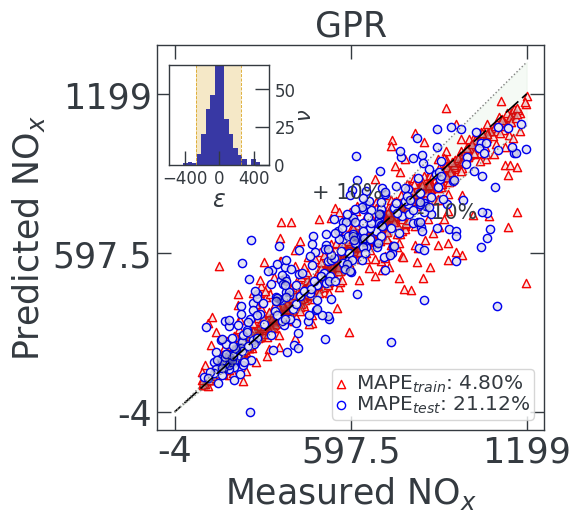

In [ ]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
pipeline = Pipeline([      
    ('scaler_X', StandardScaler()), 
    ('model', TransformedTargetRegressor(
        regressor= GaussianProcessRegressor(random_state=3),
        transformer=StandardScaler()))
])
hyperparameter_grid = {
    "kernel": (
        # Matern + WhiteKernel
        [
            ConstantKernel(1.0, (1e-3, 1e3)) *
            Matern(length_scale=ls, nu=nu) +
            WhiteKernel(noise_level=noise)
            for ls in [0.1, 0.5, 1, 2, 5, 10]
            for nu in [0.5, 1.5, 2.5]
            for noise in [1e-5, 1e-3, 1e-1, 1]
        ]
        +
        # RBF + WhiteKernel
        [
            ConstantKernel(1.0, (1e-3, 1e3)) *
            RBF(length_scale=ls) +
            WhiteKernel(noise_level=noise)
            for ls in [0.1, 0.5, 1, 2, 5, 10]
            for noise in [1e-5, 1e-3, 1e-1, 1]
        ]
        +
        # RationalQuadratic + WhiteKernel
        [
            ConstantKernel(1.0, (1e-3, 1e3)) *
            RationalQuadratic(length_scale=ls, alpha=alpha) +
            WhiteKernel(noise_level=noise)
            for ls in [0.1, 0.5, 1, 2, 5, 10]
            for alpha in [0.1, 0.5, 1, 2]
            for noise in [1e-5, 1e-3, 1e-1, 1]
        ]
    ),
    "alpha": [1e-10, 1e-5, 1e-3, 1e-2, 1e-1, 1],
    "normalize_y": [True, False],
}

iterations =200
best_regressor,random_search = RandomSearchCV_pipeline(pipeline, flatten_grid(hyperparameter_grid), X_train, y_train, 
                                                       iterations = iterations, verbose= 1)
random_search.best_params_
end_profiling(save_path = '/home/m3rg2000/Junaid_temporary/saved_data/Time_cpu_stats/plant3/gpr_rand_SearchCV.txt',
              note = 'RandomSearchCV for plant 3 gpr')

save_model(best_regressor,
           model_path = f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant3/gpr_best.pkl')

# save Randomsearch results
log_search_space(random_search.cv_results_ , file_note = None,log_file_path= "/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant3/gpr.txt")
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant3/{titles[7]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[7],'NO$_{x}$', X_train, X_test, y_train, y_test, avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

Pipeline(steps=[('scaler_X', StandardScaler()),
                ('model',
                 TransformedTargetRegressor(regressor=GaussianProcessRegressor(alpha=0.1,
                                                                               kernel=1**2 * RBF(length_scale=0.5) + WhiteKernel(noise_level=1),
                                                                               random_state=3),
                                            transformer=StandardScaler()))])

Avg Training:  R^2 = 0.92, MAE = 55.6, MAPE = 12.34%
Avg Val:  R^2 = 0.71, MAE = 109.58, MAPE = 26.14%
Test 0.75 100.64 24.13


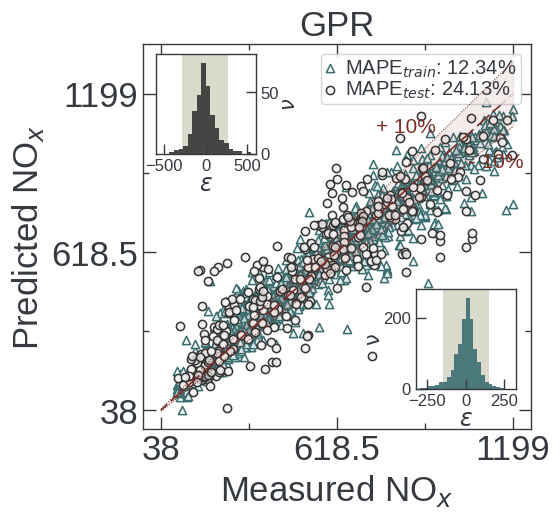

In [12]:
# Iteration 
np.random.seed(1002)
random.seed(0)

regressor = GaussianProcessRegressor(random_state = 3,
normalize_y= False, kernel= 1**2 * RBF(length_scale=0.5) + WhiteKernel(noise_level=1), alpha= 0.1)
pipeline = Pipeline([      
    ('scaler_X', StandardScaler()), 
    ('model', TransformedTargetRegressor(
        regressor= regressor,
        transformer=StandardScaler()))
])
pipeline.fit(X_train, y_train)
avg_train_results, avg_val_results = k_fold_scores(pipeline, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant3/{titles[7]}_parity.pdf'
test_results = parity_train_test(pipeline, titles[7],'NO$_{x}$', X_train, X_test, y_train, y_test, avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

# NN

GPU 0: Utilization: 0%, Memory Used: 298 MB / 12282 MB
Fitting 1 folds for each of 150 candidates, totalling 150 fits


{'model__regressor__verbose': False,
 'model__regressor__validation_fraction': 0.2,
 'model__regressor__solver': 'adam',
 'model__regressor__random_state': 42,
 'model__regressor__n_iter_no_change': 20,
 'model__regressor__max_iter': 500,
 'model__regressor__learning_rate_init': 0.003,
 'model__regressor__hidden_layer_sizes': (256, 128),
 'model__regressor__early_stopping': True,
 'model__regressor__batch_size': 128,
 'model__regressor__alpha': 0.1,
 'model__regressor__activation': 'relu'}

GPU 0: Utilization: 0%, Memory Used: 298 MB / 12282 MB
---- NOTE ----
RandomSearchCV for plant 3 nn

---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 298 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 298 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 117.4615 s
System CPU time  : 0.0924 s
Total CPU time   : 117.5539 s
Wall clock time  : 117.7820 s

---- CPU Utilization Stats ----
Avg CPU usage    : 1.56%
Max CPU usage    : 1.59%
Logical cores    : 64
Physical cores   : 32
Avg Training:  R^2 = 0.84, MAE = 81.4, MAPE = 18.84%
Avg Val:  R^2 = 0.68, MAE = 112.82, MAPE = 26.28%
Test 0.69 111.49 24.74


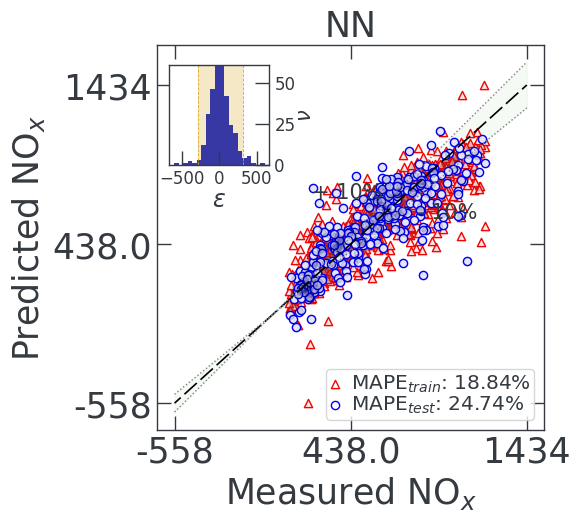

In [ ]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
pipeline = Pipeline([      
    ('scaler_X', StandardScaler()), 
    ('model', TransformedTargetRegressor(
        regressor= MLPRegressor(),
        transformer=StandardScaler()))
])
hyperparameter_grid = {
    'hidden_layer_sizes': [
        (64,), (128,), (256,),          # Single layer
        (64, 32), (128, 64), (256, 128), # Two layers
        (128, 64, 32), (64, 32, 16)      # Three layers (only for more data)
    ],
    'activation': ['relu'],
    'learning_rate_init': [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    'batch_size': [16, 32, 64, 128],
    'solver': ['adam'],  # 'lbfgs' works better for small datasets, 'adam' for large
    'early_stopping': [True],  # Keep fixed if you're using validation
    'n_iter_no_change': [20],
    'validation_fraction': [0.2],
    'max_iter': [500],
    'random_state': [42], 
    'verbose': [False]
}
iterations =150
best_regressor,random_search = RandomSearchCV_pipeline(pipeline, flatten_grid(hyperparameter_grid), X_train, y_train,  # ravel for NN
                                                       iterations = iterations, verbose= 1)

random_search.best_params_
end_profiling(save_path = '/home/m3rg2000/Junaid_temporary/saved_data/Time_cpu_stats/plant3/nn_rand_SearchCV.txt',
              note = 'RandomSearchCV for plant 3 nn')
save_model(best_regressor,
           model_path = f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant3/nn_best.pkl') # =None if not want to save

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path = "/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant3/co_nn.txt")
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)  
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant3/{titles[8]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[8],'NO$_{x}$', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

Pipeline(steps=[('scaler_X', StandardScaler()),
                ('model',
                 TransformedTargetRegressor(regressor=MLPRegressor(alpha=0.1,
                                                                   batch_size=32,
                                                                   early_stopping=True,
                                                                   hidden_layer_sizes=(128,
                                                                                       64),
                                                                   learning_rate_init=0.01,
                                                                   max_iter=500,
                                                                   n_iter_no_change=20,
                                                                   random_state=42,
                                                                   validation_fraction=0.2),
                                            transformer=StandardScaler()))])

Avg Training:  R^2 = 0.81, MAE = 90.11, MAPE = 21.02%
Avg Val:  R^2 = 0.68, MAE = 115.17, MAPE = 26.1%
Test 0.72 111.89 25.35


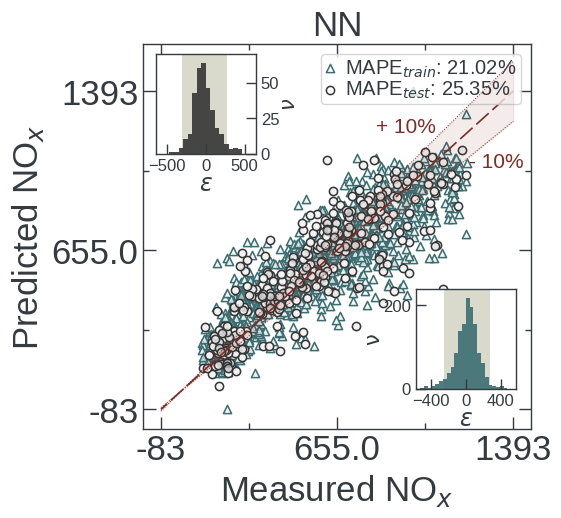

In [13]:
# Iteration 
np.random.seed(1002)
random.seed(0)

regressor = MLPRegressor(
verbose= False, validation_fraction= 0.2, solver= "adam", random_state= 42, n_iter_no_change= 20, max_iter= 500, learning_rate_init= 0.01, hidden_layer_sizes= (128, 64), early_stopping= True, batch_size= 32, alpha= 0.1, activation= "relu"
)
pipeline = Pipeline([      
    ('scaler_X', StandardScaler()), 
    ('model', TransformedTargetRegressor(
        regressor= regressor,
        transformer=StandardScaler()))
])
pipeline.fit(X_train, y_train)
avg_train_results, avg_val_results = k_fold_scores(pipeline, X_train, y_train)  
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant3/{titles[8]}_parity.pdf'
test_results = parity_train_test(pipeline, titles[8],'NO$_{x}$', X_train, X_test, y_train, y_test, avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

In [15]:
train_scores = [(0.54, 148.28, 37.51),
 (0.54, 148.28, 37.51),
 (0.54, 148.47, 37.56),
 (0.52, 152.89, 38.09),
 (0.76, 101.72, 24.43),
 (0.87, 72.96, 16.09),
 (0.8, 77.12, 15.79),
 (0.92, 55.6, 12.34),
 (0.81, 90.11, 21.02)]

val_scores = [(0.51, 152.74, 38.81),
 (0.51, 152.73, 38.81),
 (0.51, 152.95, 38.88),
 (0.48, 158.17, 39.73),
 (0.66, 122.23, 29.09),
 (0.71, 109.64, 24.51),
 (0.69, 110.87, 24.4),
 (0.71, 109.58, 26.14),
 (0.68, 115.17, 26.1)]

test_scores = [(0.56, 143.38, 36.13),
 (0.56, 143.33, 36.12),
 (0.56, 142.93, 36.01),
 (0.54, 146.75, 36.39),
 (0.72, 107.14, 24.33),
 (0.77, 94.2, 19.95),
 (0.74, 104.08, 23.17),
 (0.75, 100.64, 24.13),
 (0.72, 111.89, 25.35)]

with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant3_train.pkl", "wb") as f:  
    pickle.dump(train_scores, f)
    
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant3_val.pkl", "wb") as f:  
    pickle.dump(val_scores, f)
    
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant3_test.pkl", "wb") as f:  
    pickle.dump(test_scores, f)